# Partición

```{admonition} Alcance
:class: tip
El corte se decidió antes del análisis exploratorio: el conjunto de prueba (*test*) son los
últimos cuatro meses, de mayo a agosto de 2026 (constante `CORTE` en `comun.py`).
```

## Por qué un corte en el tiempo

El modelo se usaría para predecir, con la información disponible hoy, quién renuncia el mes
siguiente, y la evaluación debe reproducir ese uso. Una partición aleatoria por filas pondría meses
futuros en el entrenamiento (el modelo aprendería de agosto para predecir marzo) y meses de una
misma persona en los dos conjuntos. Con el corte cronológico, todo lo que el modelo ve es anterior
a lo que predice.

Las mismas personas aparecen en entrenamiento y en test, porque es un panel y quien estaba en abril
sigue en mayo. Esto no constituye una fuga: en producción el modelo también puntúa a personas que
ya conoce. Habría fuga si la etiqueta de un mes de test entrara al entrenamiento, y el corte lo
impide.

## Uso previo del panel completo

Para construir el panel se exploraron todos los meses: se definieron las exclusiones, se unificaron
los cargos, se descartaron campos redundantes y se revisaron las fugas. Son decisiones de calidad de
datos (qué es un aprendiz, qué campo repite a otro, qué dato está mal registrado) y ninguna se tomó
según su capacidad predictiva. A partir de aquí el test queda reservado: el análisis exploratorio,
la selección de variables y el ajuste usan solo el entrenamiento, y el test se usa una vez, en el
capítulo 7.

In [1]:
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
from comun import (cargar, particion, estilo, etiquetar, OBJETIVO, PREDICTORAS, CORTE,
                   VERDE, ORO, BORDE)

estilo()

p = cargar()
tr, te = particion(p)

resumen = pd.DataFrame({
    'meses': [tr.mes.nunique(), te.mes.nunique()],
    'desde': [tr.mes.min(), te.mes.min()],
    'hasta': [tr.mes.max(), te.mes.max()],
    'filas': [len(tr), len(te)],
    '% filas': [round(100 * len(tr) / len(p), 1), round(100 * len(te) / len(p), 1)],
    'personas': [tr.persona_id.nunique(), te.persona_id.nunique()],
    'renuncias': [int(tr[OBJETIVO].sum()), int(te[OBJETIVO].sum())],
    'prevalencia %': [round(100 * tr[OBJETIVO].mean(), 2), round(100 * te[OBJETIVO].mean(), 2)],
}, index=['entrenamiento', 'test'])
resumen

,meses,desde,hasta,filas,% filas,personas,renuncias,prevalencia %
entrenamiento,16,2025-01,2026-04,67530,79.2,5508,730,1.08
test,4,2026-05,2026-08,17693,20.8,4622,162,0.92


personas en los dos conjuntos: 4,383 | personas que solo aparecen en test (ingresos nuevos): 239


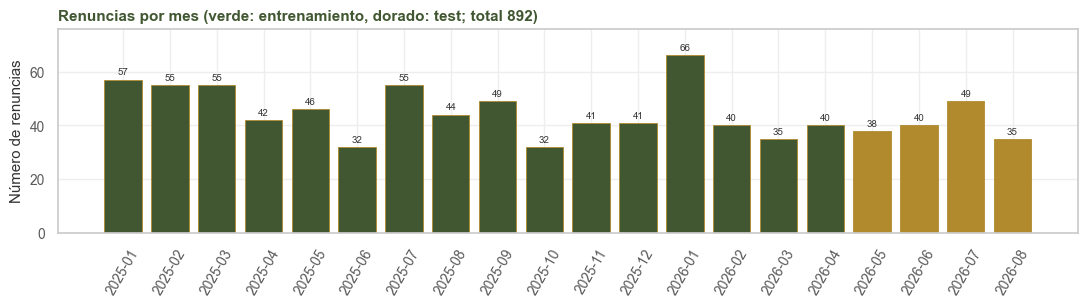

In [2]:
en_ambos = len(set(tr.persona_id) & set(te.persona_id))
nuevas = te.loc[~te.persona_id.isin(tr.persona_id), 'persona_id'].nunique()
print(f'personas en los dos conjuntos: {en_ambos:,} | '
      f'personas que solo aparecen en test (ingresos nuevos): {nuevas:,}')

por_mes = p.groupby('mes').agg(filas=(OBJETIVO, 'size'), renuncias=(OBJETIVO, 'sum'))
colores = [VERDE if mes < CORTE else ORO for mes in por_mes.index]

fig, ax = plt.subplots(figsize=(11, 3.2))
barras = ax.bar(por_mes.index, por_mes.renuncias, color=colores, **BORDE)
etiquetar(ax, barras)
ax.set(title=f'Renuncias por mes (verde: entrenamiento, dorado: test; '
             f'total {int(por_mes.renuncias.sum())})',
       ylabel='Número de renuncias')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

## Validación dentro del entrenamiento

La validación cruzada sigue la misma lógica de la partición: es cronológica, con ventana creciente
por mes y un mes de separación (`gap`). Cada pliegue valida un mes, de septiembre de 2025 a abril de
2026, y entrena con todos los meses anteriores salvo el inmediatamente previo. La separación se
debe a que una renuncia puede quedar registrada en SAP ya entrado el mes siguiente, de modo que al
predecir el mes *t* la etiqueta de *t−1* puede no estar disponible. Con esta validación se eligen el
hiperparámetro y el tamaño de la lista (capítulo 7).

Como complemento se usa una validación de cinco pliegues agrupada por persona (`GroupKFold`), en la
que todos los meses de una persona caen en el mismo pliegue. Mide si el modelo generaliza a personas
que no vio.

## Duplicados y entidades entre particiones

In [3]:
print('filas persona-mes duplicadas en el panel:', p.duplicated(['persona_id', 'mes']).sum())

pares_tr = set(zip(tr.persona_id, tr.mes))
pares_te = set(zip(te.persona_id, te.mes))
print('pares (persona, mes) en entrenamiento y test a la vez:', len(pares_tr & pares_te))

# vectores de predictoras del test que aparecen idénticos en el entrenamiento
vec_tr = set(map(tuple, tr[PREDICTORAS].astype(str).to_numpy()))
vec_te = te[PREDICTORAS].astype(str).apply(tuple, axis=1)
igual = vec_te.isin(vec_tr).to_numpy()
print(f'filas de test con un vector idéntico en entrenamiento: {igual.sum():,} de {len(te):,} '
      f'({100 * igual.mean():.0f} %)')
print(f'  antigüedad mediana: {te[igual].antig_meses.median():.0f} meses '
      f'(resto del test: {te[~igual].antig_meses.median():.0f})')
operario = te[igual].oficio.eq('operario_campo_general').mean()
print(f'  operario_campo_general: {100 * operario:.0f} %')
print(f'  personas que también están en entrenamiento: '
      f'{100 * te[igual].persona_id.isin(tr.persona_id).mean():.0f} %')

filas persona-mes duplicadas en el panel: 0
pares (persona, mes) en entrenamiento y test a la vez: 0


filas de test con un vector idéntico en entrenamiento: 1,732 de 17,693 (10 %)
  antigüedad mediana: 13 meses (resto del test: 46)
  operario_campo_general: 41 %
  personas que también están en entrenamiento: 91 %


Ninguna fila está en los dos conjuntos. Un 10 % de las filas de test tiene un vector de predictoras
idéntico a alguno del entrenamiento; como se vio en la sección 1.5, son personas distintas con el
mismo perfil, frecuentes en fincas con muchos operarios del mismo tipo. No hay fuga, porque la
etiqueta de test corresponde a un mes posterior.

## Síntesis

- El test son los cuatro últimos meses (17.693 filas y 162 renuncias) y se usa una sola vez.
- La validación dentro del entrenamiento es temporal, con un mes de separación; la agrupada por
  persona es un complemento.
- Desde aquí, todas las tablas y figuras del análisis exploratorio usan solo el entrenamiento.